In [1]:
try:
    import google.colab  # noqa: F401

    %pip install -q dataeval[onnx] maite-datasets
except Exception:
    pass

In [2]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from maite_datasets.image_classification import CIFAR10, MNIST
from torch import nn

from dataeval.config import set_seed
from dataeval.data import Indices, Limit, Select, Shuffle
from dataeval.extractors import ScoresExtractor, UncertaintyExtractor
from dataeval.models import OnnxImageClassifier
from dataeval.shift import DriftWasserstein

set_seed(0, all_generators=True)

In [3]:
class TinyCNN(nn.Module):
    """A small MNIST classifier emitting raw logits."""

    def __init__(self) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class WithSoftmax(nn.Module):
    """Wrap a logits model so its ONNX ``scores`` output is a probability distribution."""

    def __init__(self, base: nn.Module) -> None:
        super().__init__()
        self.base = base

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.softmax(self.base(x), dim=1)

In [4]:
# Train the demo classifier on a small slice of MNIST (a few seconds on CPU).
mnist_train = MNIST("./data", image_set="train", download=True)
train_ids = np.random.default_rng(0).permutation(len(mnist_train))[:4000]
x_train = torch.tensor(np.stack([np.asarray(mnist_train[i][0], dtype=np.float32) / 255.0 for i in train_ids]))
y_train = torch.tensor(np.stack([np.asarray(mnist_train[i][1]).argmax() for i in train_ids]))

model = TinyCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
model.train()
for _ in range(3):
    order = torch.randperm(len(x_train))
    for start in range(0, len(x_train), 128):
        batch = order[start : start + 128]
        optimizer.zero_grad()
        loss_fn(model(x_train[batch]), y_train[batch]).backward()
        optimizer.step()
model.eval()

TinyCNN(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1568, out_features=10, bias=True)
  )
)

In [5]:
Path("data").mkdir(exist_ok=True)
model_path = "data/mnist-demo.onnx"
metadata_path = "data/mnist-demo-metadata.json"

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    torch.onnx.export(
        WithSoftmax(model).eval(),
        (torch.zeros(1, 1, 28, 28),),
        model_path,
        input_names=["image"],
        output_names=["scores"],
        dynamic_axes={"image": {0: "batch"}, "scores": {0: "batch"}},
        opset_version=13,
        dynamo=False,
    )

_ = Path(metadata_path).write_text(
    json.dumps({
        "interface": {"name": "JATIC_ONNX", "version": "v1"},
        "io": {
            "batchSize": -1,
            "interface": "IMAGE_CLASSIFICATION",
            "input": {"channels": "GRAYSCALE", "height": 28, "width": 28},
            "output": {"nClasses": 10},
        },
    }),
    encoding="utf-8",
)

In [6]:
SAMPLES_PER_SPLIT = 200

mnist_test = MNIST("./data", image_set="test", download=True)

# Three disjoint, exchangeable MNIST slices: two references that calibrate the baseline
# (train, val) and a held-out set that should NOT drift (test).
perm = np.random.default_rng(1).permutation(len(mnist_test))
train_idx, val_idx, test_idx = np.array_split(perm[: 3 * SAMPLES_PER_SPLIT], 3)
trainset = Select(mnist_test, Indices(train_idx.tolist()))
valset = Select(mnist_test, Indices(val_idx.tolist()))
testset = Select(mnist_test, Indices(test_idx.tolist()))

# Shifted "operational" data: CIFAR-10 natural images
cifarset = Select(CIFAR10("./data", image_set="test", download=True), [Shuffle(0), Limit(SAMPLES_PER_SPLIT)])

print(f"train: {len(trainset)}  val: {len(valset)}  test: {len(testset)}  cifar: {len(cifarset)}")

train: 200  val: 200  test: 200  cifar: 200


In [7]:
classifier = OnnxImageClassifier(model_path, metadata_path)
scores = ScoresExtractor(classifier)
uncertainty = UncertaintyExtractor(scores, preds_type="probs", normalize=True)

print(uncertainty)

2026-07-02 02:34:16.186735682 [W:onnxruntime:Default, device_discovery.cc:325 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:92 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


UncertaintyExtractor(scores=ScoresExtractor, preds_type='probs', normalize=True)


In [8]:
h_train = uncertainty(trainset)
h_val = uncertainty(valset)
h_test = uncertainty(testset)
h_cifar = uncertainty(cifarset)

print(
    f"mean entropy -> train: {h_train.mean():.3f}  val: {h_val.mean():.3f}  "
    f"test: {h_test.mean():.3f}  cifar: {h_cifar.mean():.3f}"
)

mean entropy -> train: 0.183  val: 0.190  test: 0.191  cifar: 0.452


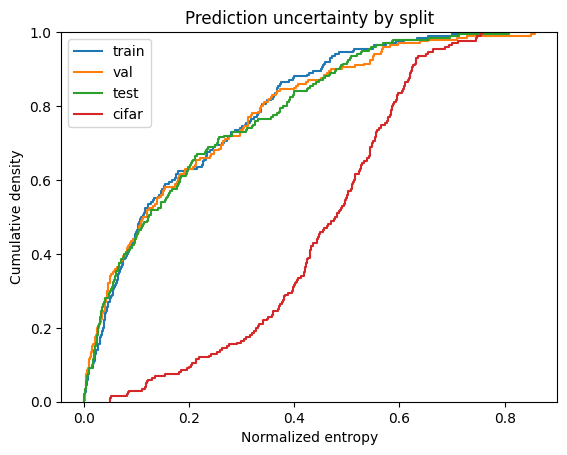

In [9]:
plt.figure()
for label, h in [("train", h_train), ("val", h_val), ("test", h_test), ("cifar", h_cifar)]:
    plt.ecdf(h.flatten(), label=label)
plt.xlabel("Normalized entropy")
plt.ylabel("Cumulative density")
plt.title("Prediction uncertainty by split")
plt.legend()
plt.show()

In [10]:
drift_detector = DriftWasserstein().fit(np.asarray(h_train), np.asarray(h_val))

result_test = drift_detector.predict(np.asarray(h_test))
print(f"MNIST held-out -> drift: {result_test.drifted}  (ratio: {result_test.distance:.2f})")

result_cifar = drift_detector.predict(np.asarray(h_cifar))
print(f"CIFAR-10       -> drift: {result_cifar.drifted}  (ratio: {result_cifar.distance:.2f})")

MNIST held-out -> drift: False  (ratio: 1.07)
CIFAR-10       -> drift: True  (ratio: 18.48)


In [11]:
# TEST ASSERTION CELL ###
assert h_cifar.mean() > h_test.mean()
assert result_cifar.drifted
assert not result_test.drifted